# Getting Started: Bayesian Workflow with ProbPipe

This tutorial walks through an iterative Bayesian modeling workflow using ProbPipe, following the principles outlined in [Bayesian Workflow](https://arxiv.org/abs/2011.01808) (Gelman et al., 2020). The key idea is that applied Bayesian analysis is *iterative*: we start with a simple model, check it against data, revise, and repeat. ProbPipe is designed to make this process computationally efficient and statistically rigorous.

### ProbPipe's core principle: distributions in, distributions out

ProbPipe's design revolves around two universal containers:

- **`Distribution`** — represents random quantities (priors, posteriors, data-generating processes). Every operation that takes a distribution returns a distribution: *distributions in, distributions out*.
- **`Values`** — represents fixed structured data (observed datasets, hyperparameters, design matrices). `Values` is the deterministic counterpart of `Distribution` — a container for named fields that are known rather than uncertain.

Both `Values` and `Distribution` support **named fields** and a **`select()`** method, which makes it easy to pass specific fields into workflow functions via splatting (e.g., `predict(**posterior.select("intercept", "slope"))`).

### Abstract components of a probabilistic workflow

Most workflows for probabilistic inference can be described in terms of four **abstract components**:

1. **Distributions** — priors, posteriors, data products.
2. **Fixed inputs** — data and hyperparameters, represented as `Values`.
3. **Operations** that transform distributions — conditioning, pushforwards, expectations.
4. **Differentiation** with respect to fixed inputs.

Implementing these workflows, however, is harder than describing them:

- **Algorithmic challenges** — many possible algorithms exist for the same operation. A posterior could be approximated using different Markov chain Monte Carlo (MCMC) algorithms, variational inference, or sequential Monte Carlo. These are implemented across many packages and often not designed to be directly compatible.
- **Representational challenges** — algorithms require or output specific distribution formats that may not be compatible with other parts of the workflow. For example, MCMC outputs a discrete approximation to a distribution, but many MCMC algorithms require continuous parametric priors.

ProbPipe manages representations and algorithms automatically by default, while giving you control over these choices when you want it:

- **`Distribution`s** are immutable and declare capabilities via protocols (`SupportsSampling`, `SupportsLogProb`, ...). Every distribution carries **provenance** metadata that records its lineage — which operations produced it and from which inputs — enabling reproducibility and debugging. ProbPipe converts between representations as needed, or you can choose a specific representation explicitly.
- **`WorkflowFunction`s** compute **pushforward distributions** automatically — you write a function that takes fixed values, and ProbPipe propagates uncertainty when those values are in fact unknown.
- **`Module`s** group related workflow functions with shared state, enabling reusable inferential components (e.g., `IncrementalConditioner` chains posterior updates across data batches, managing density estimation and re-conditioning internally).

ProbPipe provides a set of built-in **ops** — special workflow functions that dispatch on a distribution's protocols. These include:

- **`condition_on`** — condition a distribution (such as a joint model over data and parameters) on observed information (such as observed data), automatically selecting the best inference algorithm (or specify one with `method=`).
- **`from_distribution`** — convert between distribution representations (e.g., TensorFlow Probability (TFP) ↔ ProbPipe ↔ scipy) via the converter registry.
- **`mean`**, **`variance`**, **`cov`**, **`expectation`** — compute distributional summaries, with automatic Monte Carlo fallback when exact computation is unavailable. When using Monte Carlo approximation, these ops return a `BootstrapDistribution` that characterizes the numerical uncertainty of the estimate.
- **`sample`**, **`log_prob`** — draw samples or evaluate densities through a uniform interface.
- **`predictive_check`** — built-in prior and posterior predictive checking.

## Running example: modeling count data

To illustrate ProbPipe's features, we analyze the **horseshoe crab satellite** dataset (Brockmann, 1996; Agresti, 2007). Each nesting female horseshoe crab may attract "satellite" males. The response is the **count of satellites**, with the female's **carapace width** (cm) as the primary covariate.

In [1]:
import warnings
warnings.filterwarnings('ignore', message=r'Explicitly requested dtype.*float64.*')
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import jax, jax.numpy as jnp, numpy as np, matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import tensorflow_probability.substrates.jax.glm as tfp_glm

from probpipe import (
    Values, Normal, ProductDistribution,
    EmpiricalDistribution, BootstrapReplicateDistribution,
    GLMLikelihood, SimpleModel,
    condition_on, from_distribution, sample, mean, variance,
    workflow_function, predictive_check, provenance_ancestors,
)
from probpipe.modeling import IncrementalConditioner

In [2]:
# Load horseshoe crab data (Brockmann 1996, Agresti 2007)
df = pd.read_csv("data/horseshoe_crabs.csv")
ds = xr.Dataset.from_dataframe(df)

# Explore with xarray
print(ds)
print(f"\nWidth: mean={float(ds.width_cm.mean()):.1f}, std={float(ds.width_cm.std()):.1f}")
print(f"Satellites: mean={float(ds.satellites.mean()):.1f}, max={int(ds.satellites.max())}")

<xarray.Dataset> Size: 4kB
Dimensions:     (index: 172)
Coordinates:
  * index       (index) int64 1kB 0 1 2 3 4 5 6 ... 165 166 167 168 169 170 171
Data variables:
    width_cm    (index) float64 1kB 28.3 22.5 26.0 24.8 ... 23.5 26.5 25.5 22.5
    satellites  (index) int64 1kB 8 0 9 0 4 0 0 0 0 0 0 ... 0 15 0 2 3 0 0 6 3 1

Width: mean=25.9, std=1.9
Satellites: mean=2.3, max=15


In [3]:
# Extract arrays and standardize covariates
x_width = jnp.asarray(ds.width_cm.values, dtype=jnp.float32)
y_sat = jnp.asarray(ds.satellites.values, dtype=jnp.float32)
x_mean, x_std = float(x_width.mean()), float(x_width.std())
x_z = (x_width - x_mean) / x_std
X = jnp.column_stack([jnp.ones_like(x_z), x_z])

## 1. Choose an initial model

We start simple: a **Poisson regression** for count data, $y_i \sim \text{Poisson}(\exp(\boldsymbol{x}_i^\top \boldsymbol{\beta}))$.

`GLMLikelihood` wraps a TFP generalized linear model (GLM) family and a design matrix into a ProbPipe likelihood that supports both inference and data generation. Models can also be defined using PyMC, Stan, or TFP directly (see §10).

In [4]:
lik_poisson = GLMLikelihood(tfp_glm.Poisson(), X)
# Named prior — posterior draws will have .intercept and .slope fields
prior = ProductDistribution(
    intercept=Normal(loc=0.0, scale=jnp.sqrt(5.0)),
    slope=Normal(loc=0.0, scale=jnp.sqrt(5.0)),
)
model_poisson = SimpleModel(prior, lik_poisson, name='poisson')

## 2. Prior predictive checking

Before fitting, we check whether the prior implies plausible data. `predictive_check` draws parameters from the prior, generates replicated data, and computes a summary statistic. Without `observed_data`, it acts as a **prior predictive check**.

In [5]:
prior_check = predictive_check(
    prior, lik_poisson, test_fn=lambda d: float(jnp.mean(d)),
    n_samples=len(y_sat),
)
prior_means = np.array(prior_check['replicated_statistics'].samples)
print(f'Prior predictive mean: median={np.median(prior_means):.1f}, '
      f'90th pct={np.percentile(prior_means, 90):.1f}')
print(f'Observed mean: {y_sat.mean():.2f}')

Prior predictive mean: median=5.7, 90th pct=1003.7
Observed mean: 2.34


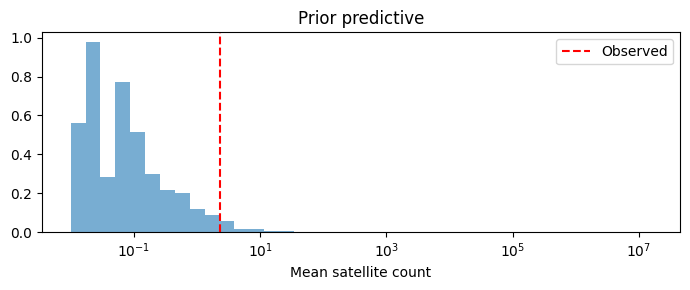

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
bins = np.logspace(np.log10(max(prior_means.min(), 0.01)),
                   np.log10(prior_means.max()), 40)
ax.hist(prior_means, bins=bins, density=True, alpha=0.6)
ax.axvline(y_sat.mean(), color='red', ls='--', label='Observed')
ax.set(xlabel='Mean satellite count', title='Prior predictive')
ax.set_xscale('log'); ax.legend()
plt.tight_layout(); plt.show()

## 3. Fit the model

`condition_on` runs MCMC via the **inference method registry**, which auto-selects the best available algorithm — the No-U-Turn Sampler (NUTS) when the log-density is JAX-traceable, gradient-free random-walk Metropolis–Hastings (RWMH) otherwise. Pass `method="tfp_hmc"` (or any registered name) to override. The result is an `ApproximateDistribution` with chain structure and diagnostics.

In [7]:
posterior_poisson = condition_on(
    model_poisson, jnp.asarray(y_sat),
)
print(f'Posterior mean: {mean(posterior_poisson)}')
print(posterior_poisson.diagnostics)

Posterior mean: [0.664816  0.6006607]


AttributeError: 'ApproximateDistribution' object has no attribute 'diagnostics'

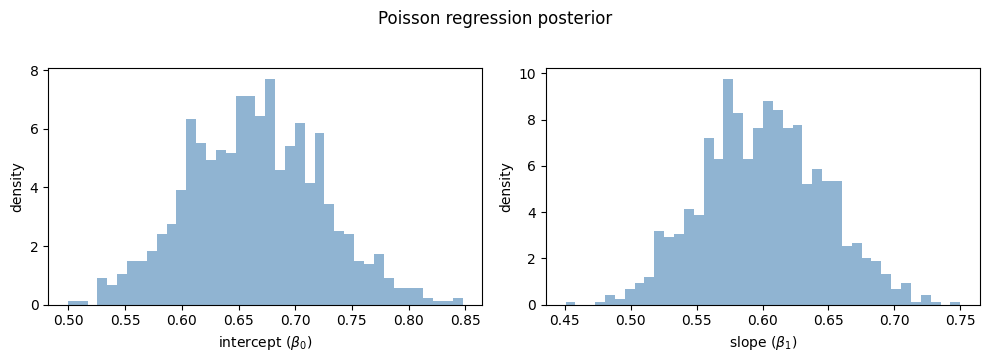

In [9]:
draws = posterior_poisson.draws()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, name in zip(axes, ['intercept', 'slope']):
    label = f'{name} ($\\beta_0$)' if name == 'intercept' else f'{name} ($\\beta_1$)'
    ax.hist(np.asarray(getattr(draws, name)), bins=40, density=True, alpha=0.6, color='steelblue')
    ax.set(xlabel=label, ylabel="density")
plt.suptitle('Poisson regression posterior', y=1.02)
plt.tight_layout(); plt.show()

## 4. Provenance tracking

Every distribution records how it was created — the algorithm, parents, and metadata. This enables full lineage tracing from any result back to its inputs.

In [10]:
print(posterior_poisson.source)
print(f'Ancestors: {[type(a).__name__ for a in provenance_ancestors(posterior_poisson)]}')

Provenance('tfp_nuts', parents=[ProductDistribution])
Ancestors: ['ProductDistribution']


## 5. Posterior predictive checking

Does the fitted model reproduce key features of the data? With `observed_data`, `predictive_check` also returns a calibration **p-value**. We check two statistics: the **variance-to-mean ratio** (a standard overdispersion diagnostic for count data) and the **fraction of zeros**.

In [11]:
var_mean_ratio = lambda d: float(jnp.var(d) / jnp.maximum(jnp.mean(d), 1e-6))
zero_fraction = lambda d: float(jnp.mean(d == 0))

ppc_vmr = predictive_check(
    posterior_poisson, lik_poisson, var_mean_ratio, observed_data=jnp.asarray(y_sat),
)
ppc_zeros = predictive_check(
    posterior_poisson, lik_poisson, zero_fraction, observed_data=jnp.asarray(y_sat),
)
print(f"Var/mean ratio — observed: {ppc_vmr['observed_statistic']:.2f}, p={ppc_vmr['p_value']:.3f}")
print(f"Zero fraction  — observed: {ppc_zeros['observed_statistic']:.2f}, p={ppc_zeros['p_value']:.3f}")

Var/mean ratio — observed: 4.14, p=0.000
Zero fraction  — observed: 0.47, p=0.000


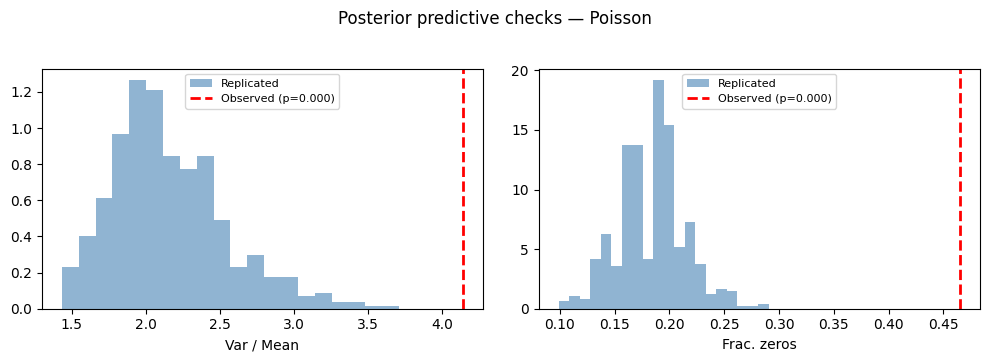

In [12]:
def plot_ppc(checks, labels, title):
    fig, axes = plt.subplots(1, len(checks), figsize=(5 * len(checks), 3.5))
    for ax, check, label in zip(axes, checks, labels):
        ax.hist(np.array(check['replicated_statistics'].samples), bins=20,
                density=True, alpha=0.6, color='steelblue', label='Replicated')
        ax.axvline(check['observed_statistic'], color='red', ls='--', lw=2,
                   label=f"Observed (p={check['p_value']:.3f})")
        ax.set(xlabel=label); ax.legend(fontsize=8)
    plt.suptitle(title, y=1.02)
    plt.tight_layout(); plt.show()

plot_ppc([ppc_vmr, ppc_zeros], ['Var / Mean', 'Frac. zeros'],
         'Posterior predictive checks — Poisson')

Both checks **fail** — the Poisson model cannot reproduce the overdispersion or the excess zeros in the observed data. This motivates revising the model.

## 6. Revise and compare models

The **negative binomial** naturally handles overdispersion. With `GLMLikelihood`, swapping is a one-line change — just replace the TFP family.

In [13]:
lik_nb = GLMLikelihood(tfp_glm.NegativeBinomial(), X)
model_nb = SimpleModel(
    # Named prior — posterior draws will have .intercept and .slope fields
    ProductDistribution(
        intercept=Normal(loc=0.0, scale=jnp.sqrt(5.0)),
        slope=Normal(loc=0.0, scale=jnp.sqrt(5.0)),
    ),
    lik_nb, name='negbin',
)

posterior_nb = condition_on(
    model_nb, jnp.asarray(y_sat),
)
print(f'NegBin posterior mean: {mean(posterior_nb)}')
print(posterior_nb.diagnostics)

NegBin posterior mean: [0.5600578  0.89335006]


AttributeError: 'ApproximateDistribution' object has no attribute 'diagnostics'

Var/mean ratio — p=0.972 (was 0.000 for Poisson)
Zero fraction  — p=0.024 (was 0.000 for Poisson)


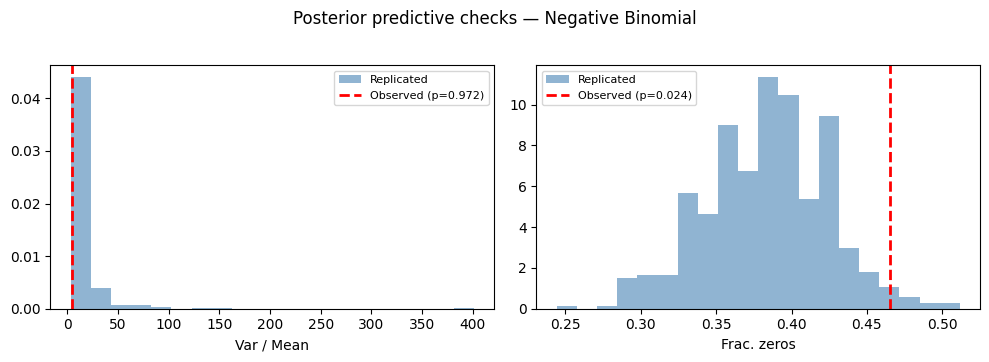

In [14]:
ppc_nb_vmr = predictive_check(
    posterior_nb, lik_nb, var_mean_ratio, observed_data=jnp.asarray(y_sat),
)
ppc_nb_zeros = predictive_check(
    posterior_nb, lik_nb, zero_fraction, observed_data=jnp.asarray(y_sat),
)
print(f"Var/mean ratio — p={ppc_nb_vmr['p_value']:.3f} (was {ppc_vmr['p_value']:.3f} for Poisson)")
print(f"Zero fraction  — p={ppc_nb_zeros['p_value']:.3f} (was {ppc_zeros['p_value']:.3f} for Poisson)")

plot_ppc([ppc_nb_vmr, ppc_nb_zeros], ['Var / Mean', 'Frac. zeros'],
         'Posterior predictive checks — Negative Binomial')

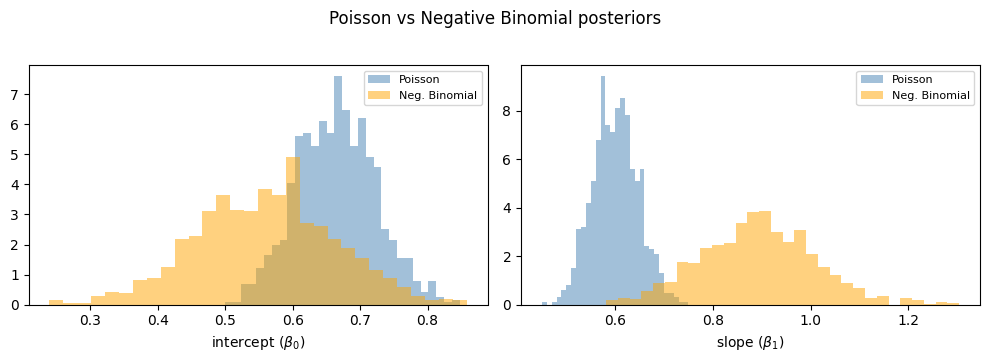

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, name in zip(axes, ['intercept', 'slope']):
    label = f'{name} ($\\beta_0$)' if name == 'intercept' else f'{name} ($\\beta_1$)'
    ax.hist(np.asarray(getattr(posterior_poisson.draws(), name)), bins=30, density=True,
            alpha=0.5, color='steelblue', label='Poisson')
    ax.hist(np.asarray(getattr(posterior_nb.draws(), name)), bins=30, density=True,
            alpha=0.5, color='orange', label='Neg. Binomial')
    ax.set(xlabel=label); ax.legend(fontsize=8)
plt.suptitle('Poisson vs Negative Binomial posteriors', y=1.02)
plt.tight_layout(); plt.show()

The negative binomial posteriors are wider — appropriately reflecting greater uncertainty once overdispersion is accounted for. The Poisson model's artificially narrow posteriors are a consequence of its misspecification.

## 7. Bagged posteriors

Under model misspecification, standard posteriors can be unreliable — credible sets from different datasets may not overlap. The **bagged posterior** (Huggins & Miller, 2024) averages over posteriors conditioned on bootstrapped datasets, yielding reproducible uncertainty quantification.

`BootstrapReplicateDistribution` wraps data as a distribution over bootstrap datasets. When `condition_on` receives a distribution where it expects fixed data, it automatically **broadcasts**: drawing bootstrap datasets, running MCMC on each, and returning the marginal over the resulting posteriors. (Pass `include_inputs=True` to retain the joint over datasets and posteriors instead.) We use `n_broadcast_samples=48` to control the number of bootstrap replicates and `parallel=True` to run MCMC fits concurrently. (For even greater scalability, ProbPipe supports Prefect orchestration to distribute fits across machines.)

We compare bagging for the Poisson and negative binomial models. If the individual posteriors are tightly clustered, the model is stable across datasets; if they spread apart, the model is sensitive to the specific dataset — a sign of misspecification. We quantify this by computing the ratio of the variance of individual posterior means to the bagged posterior variance: if sampling variability contributes more than half the total uncertainty, inference is unstable.

In [13]:
bootstrap_data = BootstrapReplicateDistribution(EmpiricalDistribution(jnp.asarray(y_sat)))

# n_broadcast_samples controls how many bootstrap datasets are drawn;
# parallel=True runs MCMC fits concurrently via threading
bagged_poisson = condition_on(
    model_poisson, bootstrap_data,
    n_broadcast_samples=16, parallel=True,
)
bagged_nb = condition_on(
    model_nb, bootstrap_data,
    n_broadcast_samples=16, parallel=True,
)

In [14]:
# Sampling variability ratio: Var(individual means) / Var(bagged posterior)
# Values > 0.5 indicate unstable inference
for label, bagged in [('Poisson', bagged_poisson), ('NegBin', bagged_nb)]:
    ind_means = np.array([np.array(mean(p)) for p in bagged.components])
    bagged_draws = np.array(sample(bagged, sample_shape=(2000,)))
    ratio = np.var(ind_means, axis=0) / np.var(bagged_draws, axis=0)
    print(f'{label}: sampling variability ratio = {np.array2string(ratio, precision=3)}')

Poisson: sampling variability ratio = [0.645 0.655]


NegBin: sampling variability ratio = [0.499 0.396]


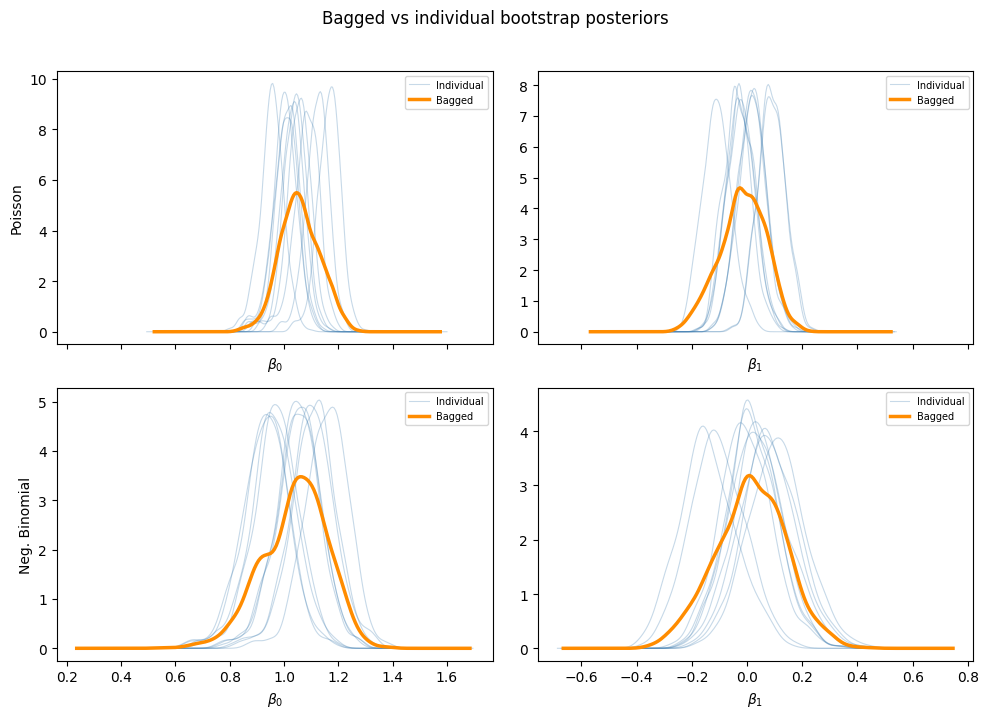

In [15]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex='col')

for row, (bagged, label) in enumerate([(bagged_poisson, 'Poisson'), (bagged_nb, 'Neg. Binomial')]):
    for col, name in enumerate(['intercept', 'slope']):
        param_label = f'{name} ($\\beta_0$)' if name == 'intercept' else f'{name} ($\\beta_1$)'
        ax = axes[row, col]
        for i, post in enumerate(bagged.components[:10]):
            d = np.array(getattr(post.draws(), name))
            xs = np.linspace(d.min() - 0.3, d.max() + 0.3, 200)
            ax.plot(xs, gaussian_kde(d)(xs), alpha=0.3, lw=0.8, color='steelblue',
                    label='Individual' if i == 0 else None)
        bd = np.array(getattr(sample(bagged, sample_shape=(2000,)), name))
        xs = np.linspace(bd.min() - 0.3, bd.max() + 0.3, 200)
        ax.plot(xs, gaussian_kde(bd)(xs), color='darkorange', lw=2.5, label='Bagged')
        ax.set(xlabel=param_label); ax.legend(fontsize=7)
        if col == 0:
            ax.set_ylabel(label)

plt.suptitle('Bagged vs individual bootstrap posteriors', y=1.02)
plt.tight_layout(); plt.show()

The Poisson individual posteriors spread apart noticeably — the model is sensitive to the particular dataset because it is misspecified. The negative binomial posteriors are more stable, reflecting a better-specified model.

## 8. Sequential updating

`IncrementalConditioner` chains posterior updates across data batches. NUTS requires a prior with a continuous density and full support, so ProbPipe automatically converts the empirical posterior to a smooth density estimate (via kernel density estimation (KDE)) before using it as the next prior.

In [16]:
batch_ends = [40, 80, 130, len(y_sat)]
batches_X = [X[:40]] + [X[s:e] for s, e in zip(batch_ends[:-1], batch_ends[1:])]
batches_y = [y_sat[:40]] + [y_sat[s:e] for s, e in zip(batch_ends[:-1], batch_ends[1:])]

post0 = condition_on(
    SimpleModel(
        # Named prior — posterior draws will have .intercept and .slope fields
        ProductDistribution(
            intercept=Normal(loc=0.0, scale=jnp.sqrt(5.0)),
            slope=Normal(loc=0.0, scale=jnp.sqrt(5.0)),
        ),
        GLMLikelihood(tfp_glm.NegativeBinomial(), batches_X[0]),
    ),
    jnp.asarray(batches_y[0]),
)

conditioner = IncrementalConditioner(
    prior=post0,
    likelihood=GLMLikelihood(tfp_glm.NegativeBinomial(), batches_X[1]),
)

seq_posteriors = [post0]
total = 40
for i in range(1, 4):
    conditioner._likelihood = GLMLikelihood(tfp_glm.NegativeBinomial(), batches_X[i])
    post = conditioner.update(data=jnp.asarray(batches_y[i]))
    seq_posteriors.append(post)
    total += len(batches_y[i])
    print(f'Batch {i+1} (n={total}): mean = {mean(post)}')

print(f'\nFull-data posterior mean: {mean(posterior_nb)}')

Batch 2 (n=80): mean = [1.1475857  0.58815664]


Batch 3 (n=130): mean = [0.96412945 0.45235032]


Batch 4 (n=173): mean = [1.0124435  0.39996845]

Full-data posterior mean: [1.000772   0.40652803]


Provenance is particularly valuable for sequential pipelines — the lineage traces back through each conditioning step, making the full chain of updates auditable.

In [17]:
ancestors = provenance_ancestors(seq_posteriors[-1])
print(f'Sequential posterior ancestors: {[type(a).__name__ for a in ancestors]}')

Sequential posterior ancestors: ['KDEDistribution', 'MCMCApproximateDistribution', 'KDEDistribution', 'MCMCApproximateDistribution', 'KDEDistribution', 'MCMCApproximateDistribution', 'MultivariateNormal']


## 9. Propagate uncertainty

As we saw with `predictive_check` and `condition_on`, ProbPipe automatically broadcasts over distributions. Here's another example: propagating posterior uncertainty through a prediction function.

In [18]:
@workflow_function
def predict_rate(intercept, slope, x):
    return jnp.exp(intercept + slope * x)

rate_dist = predict_rate(**posterior_nb.select("intercept", "slope"), x=0.0)
print(f'Rate at mean width: {float(mean(rate_dist)):.2f} '
      f'(+/- {float(jnp.sqrt(variance(rate_dist))):.2f})')

Rate at mean width: 2.70 (+/- 0.24)


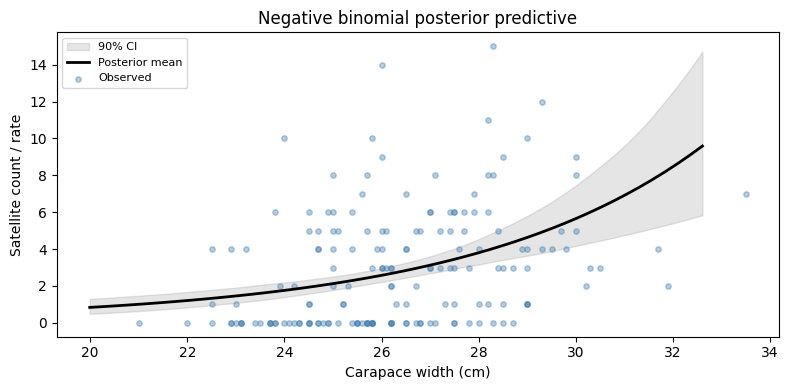

In [19]:
x_grid_z = jnp.linspace(-3, 3, 50)
x_grid_cm = x_grid_z * x_std + x_mean
draws = posterior_nb.draws()
rates = np.exp(np.asarray(draws.intercept)[:, None] + np.asarray(draws.slope)[:, None] * np.array(x_grid_z)[None, :])
lo, hi = np.percentile(rates, [5, 95], axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(x_grid_cm, lo, hi, alpha=0.2, color='gray', label='90% CI')
ax.plot(x_grid_cm, rates.mean(axis=0), 'k-', lw=2, label='Posterior mean')
ax.scatter(x_width, y_sat, s=15, alpha=0.4, color='steelblue', label='Observed')
ax.set(xlabel='Carapace width (cm)', ylabel='Satellite count / rate',
       title='Negative binomial posterior predictive')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 10. Inference registry and external backends

Every call to `condition_on` is dispatched through a pluggable **inference method registry**. The registry ranks feasible methods by priority and auto-selects the best one — but you can override with `method=`. Registered methods span MCMC algorithms (NUTS, HMC, RWMH via TFP; nutpie; CmdStan; PyMC) and variational inference (black-box variational inference (BBVI) via PyMC ADVI).

In [20]:
from probpipe.inference import inference_method_registry

# List all registered inference methods (highest priority first)
inference_method_registry.list_methods()

['tfp_nuts',
 'tfp_hmc',
 'nutpie_nuts',
 'cmdstan_nuts',
 'pymc_mcmc',
 'tfp_rwmh',
 'pymc_advi']

In [21]:
import warnings
warnings.filterwarnings('ignore', message=r'install "ipywidgets"')

import pymc as pm
from probpipe.modeling import PyMCModel

def poisson_model(y=None):
    with pm.Model() as m:
        beta = pm.Normal('beta', 0, 3, shape=2)
        rate = pm.math.exp(beta[0] + beta[1] * x_z)
        pm.Poisson('y', mu=rate, observed=y)
    return m

posterior_pymc = condition_on(PyMCModel(poisson_model), y_sat)
print(f'PyMC posterior mean: {mean(posterior_pymc)}')

PyMC posterior mean: [1.0062627 0.3457008]


Stan and nutpie are also supported — the inference registry auto-selects the right backend:

```python
# Stan (requires BridgeStan + CmdStanPy)
from probpipe.modeling import StanModel
posterior = condition_on(StanModel('model.stan'), {'y': y_sat})

# nutpie (Rust-based NUTS) — use method= to override the default
posterior = condition_on(model_poisson, y_sat, method="nutpie_nuts")

# PyMC ADVI — fast variational approximation
posterior = condition_on(PyMCModel(poisson_model), y_sat, method="pymc_advi")
```

### References

- Gelman, A., Vehtari, A., Simpson, D., et al. (2020). [Bayesian Workflow](https://arxiv.org/abs/2011.01808). *arXiv:2011.01808*.
- Brockmann, H.J. (1996). Satellite male groups in horseshoe crabs, *Limulus polyphemus*. *Ethology*, 102(1), 1–21.
- Huggins, J.H. & Miller, J.W. (2024). [Reproducible Model Selection Using Bagged Posteriors](https://doi.org/10.1214/24-EJS2237). *Electronic Journal of Statistics*, 18(2), 3709–3752.

## Next steps

- [**Flexible inference with `condition_on`**](flexible_inference.ipynb) — a second tutorial built around an ecological population model. The tractable case is fit with NUTS via `condition_on`; the same `condition_on` entry point then dispatches to amortized SBI (`sbi_learn_conditional`), to MCMC over an emulated likelihood (`sbi_learn_likelihood`), and to SMC-ABC. This is the recommended next read for seeing how ProbPipe's protocol-based dispatch lets you swap inference engines without rewriting the model.
- [**API Reference**](../api/distributions.md) — distributions, modeling primitives, inference methods, and the operation registry.
- [**Reference Notebooks**](../reference_notebooks.md) — focused examples for individual features.